In [37]:
%matplotlib inline

import os
import sys
import math

from sys import platform

sys.path.append('../../')

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from importlib.metadata import version 

import tiktoken

import torch
import torch.nn as nn



%load_ext autoreload
%autoreload 2

from llm_from_scratch.CH4.gpt import GPTModel
from llm_from_scratch.CH2.text_data_set import create_dataloader_v1
from llm_from_scratch.CH5.loss import calc_loss_batch
from llm_from_scratch.CH5.utils import find_highest_gradient
from llm_from_scratch.CH5.optim import evaluate_model, generate_and_print_sample
print(f"torch version: {version('torch')}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch version: 2.12.0


In [3]:
GPT_CONFIG_124M={'vocab_size':50257,
                 'context_length':256,
                 'emb_dim':768,
                 'n_heads':12,
                 'n_layers':12,
                 'drop_rate':0.1,
                 'qkv_bias':False}

device=torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.mps.is_available() else torch.device('cpu')
print(f"Device: {device}")

torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval(); # disable dropout during inference

Device: mps


In [5]:
filepath='../the-verdict.txt'
with open(filepath, 'r', encoding='utf-8') as f: text_data=f.read()

train_ratio=0.9
split_idx=int(train_ratio*len(text_data))
print(f"{split_idx=}")
train_loader=create_dataloader_v1(text_data[:split_idx], batch_size=2, max_length=GPT_CONFIG_124M['context_length'],
                                 stride=GPT_CONFIG_124M['context_length'], drop_last=True, shuffle=True, num_workers=0)
val_loader=create_dataloader_v1(text_data[split_idx:], batch_size=2, max_length=GPT_CONFIG_124M['context_length'],
                               stride=GPT_CONFIG_124M['context_length'], drop_last=False, shuffle=False, num_workers=0)


split_idx=18431


### Learning rate warmup

Typically the number of warm-up steps is 0.1% or 20% of the total number of steps

warmup_steps=27 total_steps=135


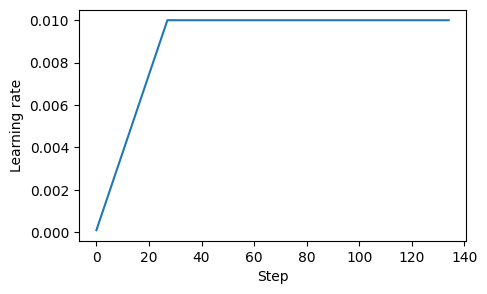

In [11]:
n_epochs=15
initial_lr=0.0001
peak_lr=0.01

total_steps=len(train_loader)*n_epochs
warmup_steps=int(0.2*total_steps) # 20% warm up steps
print(f"{warmup_steps=} {total_steps=}")

lr_increment=(peak_lr-initial_lr)/warmup_steps

global_step=-1
track_lrs=[]
optimizer=torch.optim.AdamW(model.parameters(), weight_decay=0.1)

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step+=1

        if global_step<warmup_steps: lr=initial_lr+global_step*lr_increment
        else: lr=peak_lr

        # apply the calculated learning rate to the optimizer
        for param_group in optimizer.param_groups: param_group['lr']=lr

        track_lrs.append(optimizer.param_groups[0]['lr'])


fig, ax=plt.subplots(figsize=(5,3))
ax.set_ylabel("Learning rate")
ax.set_xlabel("Step")
ax.plot(range(total_steps), track_lrs)

min_lr=1e-05
len(track_lrs)=135, total_steps=135


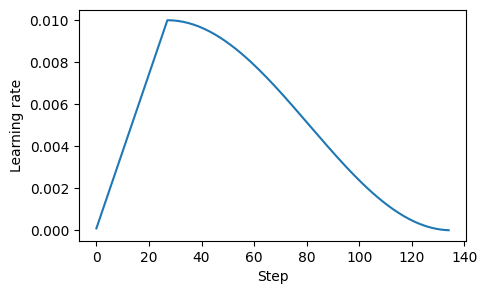

In [26]:
min_lr=0.1*initial_lr
print(f"{min_lr=}")
track_lrs=[]

lr_increment=(peak_lr-initial_lr)/warmup_steps
global_step=-1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step+=1

        # adjust the learning rate based on the current phase (warmup or cosine annealing)
        if global_step<warmup_steps: lr=initial_lr+global_step*lr_increment # linear warmup
        else: # cosine annealing after warmup
            progress=(global_step-warmup_steps)/(total_steps-warmup_steps) # [0,1]
            # progress in [0,1] so cos(progress*pi) in [1,-1] and 1+cos(progress*pi) in [2,0]
            # 0.5 normalizes [2,0] to [1,0] and then scale by (peak_lr-min_lr)
            lr=min_lr + (peak_lr-min_lr) * 0.5 * (1.+math.cos(math.pi*progress))

        # apply the calcuated learning rate to the optimizer
        for param_group in optimizer.param_groups: param_group['lr']=lr
        track_lrs.append(optimizer.param_groups[0]['lr'])

print(f"{len(track_lrs)=}, {total_steps=}")
fig, ax=plt.subplots(figsize=(5,3))
ax.set_ylabel('Learning rate')
ax.set_xlabel('Step')
ax.plot(range(total_steps), track_lrs)


### Gradient clipping

In [36]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.to(device)

loss=calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()
print(f"{find_highest_gradient(model)=}")
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.)
print(f"{find_highest_gradient(model)=}")

find_highest_gradient(model)=tensor(0.1179, device='mps:0')
find_highest_gradient(model)=tensor(0.0456, device='mps:0')
